Data retrieved for AAPL
Data retrieved for MSFT
Data retrieved for TSLA
Could not retrieve SAVE: single positional indexer is out-of-bounds
Data retrieved for GME


/tmp/ipykernel_33155/678945325.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Ticker', y='Z_Score', data=df, palette=colors)


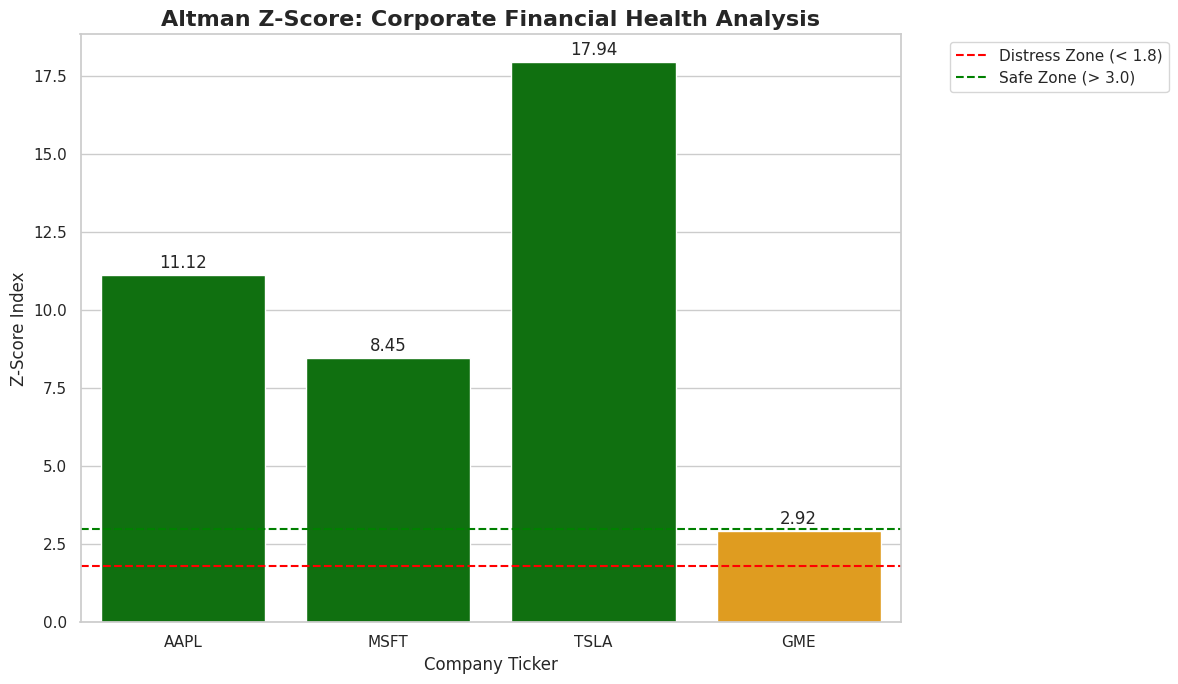


--- Summary Analysis ---
AAPL: Z-Score = 11.12 | Financial Standing: Safe
MSFT: Z-Score = 8.45 | Financial Standing: Safe
TSLA: Z-Score = 17.94 | Financial Standing: Safe
GME: Z-Score = 2.92 | Financial Standing: Grey Zone


In [1]:
# Corporate Financial Health & Bankruptcy Risk Analysis
# Methodology: Altman Z-Score Model

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Setup and Data Acquisition
# Selection includes a mix of stable (AAPL, MSFT) and historically volatile/distressed (SAVE, GME)
tickers = ['AAPL', 'MSFT', 'TSLA', 'SAVE', 'GME']

def get_financial_metrics(ticker_symbol):
    """Fetches necessary line items from Yahoo Finance"""
    ticker = yf.Ticker(ticker_symbol)

    # Get Financial Statements
    bs = ticker.balance_sheet.iloc[:, 0]      # Most recent Balance Sheet
    is_stmt = ticker.financials.iloc[:, 0]    # Most recent Income Statement
    info = ticker.info

    # Extract specific metrics
    total_assets = bs.get('Total Assets')
    current_assets = bs.get('Current Assets')
    current_liab = bs.get('Current Liabilities')
    retained_earnings = bs.get('Retained Earnings')
    ebit = is_stmt.get('EBIT')
    total_revenue = is_stmt.get('Total Revenue')
    total_liab = bs.get('Total Liabilities Net Minority Interest', bs.get('Total Liabilities'))
    market_cap = info.get('marketCap')

    # Return as dictionary
    return {
        'Ticker': ticker_symbol,
        'Working_Capital': current_assets - current_liab,
        'Total_Assets': total_assets,
        'Retained_Earnings': retained_earnings,
        'EBIT': ebit,
        'Market_Cap': market_cap,
        'Total_Liabilities': total_liab,
        'Sales': total_revenue
    }

# Fetch data for all tickers
data_list = []
for t in tickers:
    try:
        data_list.append(get_financial_metrics(t))
        print(f"Data retrieved for {t}")
    except Exception as e:
        print(f"Could not retrieve {t}: {e}")

df = pd.DataFrame(data_list)

# 2. Altman Z-Score Calculation
# Formula: Z = 1.2A + 1.4B + 3.3C + 0.6D + 1.0E
df['A'] = df['Working_Capital'] / df['Total_Assets']
df['B'] = df['Retained_Earnings'] / df['Total_Assets']
df['C'] = df['EBIT'] / df['Total_Assets']
df['D'] = df['Market_Cap'] / df['Total_Liabilities']
df['E'] = df['Sales'] / df['Total_Assets']

df['Z_Score'] = (1.2 * df['A']) + (1.4 * df['B']) + (3.3 * df['C']) + (0.6 * df['D']) + (1.0 * df['E'])

# 3. Visualization
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Create custom color mapping based on Z-Score zones
colors = ['red' if x < 1.8 else 'orange' if x < 3.0 else 'green' for x in df['Z_Score']]

ax = sns.barplot(x='Ticker', y='Z_Score', data=df, palette=colors)

# Add horizontal threshold lines
plt.axhline(1.8, color='red', linestyle='--', label='Distress Zone (< 1.8)')
plt.axhline(3.0, color='green', linestyle='--', label='Safe Zone (> 3.0)')

# Formatting
plt.title('Altman Z-Score: Corporate Financial Health Analysis', fontsize=16, fontweight='bold')
plt.ylabel('Z-Score Index')
plt.xlabel('Company Ticker')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Annotate bars with exact scores
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.tight_layout()
plt.show()

# 4. Summary Output
print("\n--- Summary Analysis ---")
for index, row in df.iterrows():
    status = "Safe" if row['Z_Score'] > 3.0 else "Grey Zone" if row['Z_Score'] > 1.8 else "Distress"
    print(f"{row['Ticker']}: Z-Score = {row['Z_Score']:.2f} | Financial Standing: {status}")